# Optimización Energética para Centro de Datos (Brasil)
**Objetivo del Proyecto:** Analizar el histórico de consumo eléctrico de Brasil (Red Interconectada Nacional) para identificar la ubicación geográfica óptima y la mejor ventana temporal para la construcción y mantenimiento de un Data Center

**Metodología:** Filtraremos el ruido de la red residencial y los sistemas aislados para enfocarnos exclusivamente en la viabilidad de la infraestructura de Alta Tensión industrial.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df_brasil = pd.read_excel("Dados brutos.xlsx")

print("--- Primeras filas del dataset de Energía ---")
display(df_brasil.head())

print("--- Informacion del Dataset ---")
df_brasil.info()

--- Primeras filas del dataset de Energía ---


,Data,TipoConsumidor,Sistema,UF,Setor Econômico - N1,Setor Econômico - N2,Setor Econômico - N3,Tipo Tensão - N1,Tipo Tensão - N2,Tipo Tensão - N3,Faixa de Consumo N1,Faixa de Consumo N2,Consumidores,Consumo
0,20140101,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
1,20140201,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
2,20140301,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0
3,20140401,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,10.0
4,20140501,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0


--- Informacion del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 285499 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Data                  285499 non-null  int64  
 1   TipoConsumidor        285499 non-null  str    
 2   Sistema               285499 non-null  str    
 3   UF                    285499 non-null  str    
 4   Setor Econômico - N1  285499 non-null  str    
 5   Setor Econômico - N2  285499 non-null  str    
 6   Setor Econômico - N3  285499 non-null  str    
 7   Tipo Tensão - N1      285499 non-null  str    
 8   Tipo Tensão - N2      285499 non-null  str    
 9   Tipo Tensão - N3      285499 non-null  str    
 10  Faixa de Consumo N1   285499 non-null  str    
 11  Faixa de Consumo N2   285499 non-null  str    
 12  Consumidores          281511 non-null  float64
 13  Consumo               275799 non-null  float64
dtypes: float64(2), int64(1), str(11

In [36]:
print("\n--- Valores exactos en la columna Sistema ---")
print(df_brasil['Sistema'].unique())

print("\n--- Valores exactos en la columna 'Tipo Tensão - N1' ---")
print(df_brasil['Tipo Tensão - N1'].unique())


--- Valores exactos en la columna Sistema ---
<StringArray>
['Sudeste / Centro-Oeste',      'Sistemas Isolados',      'Norte Interligado',
               'Nordeste',                    'Sul']
Length: 5, dtype: str

--- Valores exactos en la columna 'Tipo Tensão - N1' ---
<StringArray>
['A - Alta Tensão', 'B - Baixa Tensão']
Length: 2, dtype: str


# Preparación y Filtrado del Dataset de Operaciones

In [46]:
# 1. DEFINICIÓN DE FILTROS (MÁSCARAS)
# Aplicamos filtros de negocio y calidad simultáneamente para reducir el dataset de un solo golpe
mask_sin = ~df_brasil['Sistema'].str.contains('Isolado', case=False, na=False)
mask_tension = df_brasil['Tipo Tensão - N1'].str.contains('Alta', case=False, na=False)
mask_consumo_valido = df_brasil['Consumo'] > 1  # Esto ya elimina NaNs y negativos implícitamente

# 2. CREACIÓN DEL DATASET OPERATIVO
# Filtramos primero para trabajar con un objeto mucho más ligero en memoria
df_dc = df_brasil[mask_sin & mask_tension & mask_consumo_valido].copy()

# 3. TRANSFORMACIÓN DE TIPOS Y FECHAS
df_dc['Data'] = pd.to_datetime(df_dc['Data'].astype(str), format='%Y%m%d')
df_dc.set_index('Data', inplace=True)
df_dc.sort_index(inplace=True)

# 4. VERIFICACIÓN
print("--- Refactorización completada ---")
print(f"Filas originales: {len(df_brasil)} | Filas finales: {len(df_dc)}")
print(f"Sistemas incluidos: {df_dc['Sistema'].unique()}")
display(df_dc.head())

--- Refactorización completada ---
Filas originales: 275799 | Filas finales: 116673
Sistemas incluidos: <StringArray>
['Sudeste / Centro-Oeste', 'Sul', 'Norte Interligado', 'Nordeste']
Length: 4, dtype: str


,TipoConsumidor,Sistema,UF,Setor Econômico - N1,Setor Econômico - N2,Setor Econômico - N3,Tipo Tensão - N1,Tipo Tensão - N2,Tipo Tensão - N3,Faixa de Consumo N1,Faixa de Consumo N2,Consumidores,Consumo
Data,,,,,,,,,,,,,
2014-01-01,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
2014-01-01,Cativo,Sul,RS,Serviço Público,Tração Elétrica,TOTAL,A - Alta Tensão,A-2 - 88 a 138 kV,TOTAL,Não Aplicável,Não Aplicável,1.0,604.0
2014-01-01,Cativo,Sudeste / Centro-Oeste,SP,Poder Público,Federal,TOTAL,A - Alta Tensão,A-2 - 88 a 138 kV,TOTAL,Não Aplicável,Não Aplicável,2.0,2380.0
2014-01-01,Cativo,Norte Interligado,AM,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,43.0,823.0
2014-01-01,Livre,Norte Interligado,MA,Industrial,TOTAL,TOTAL,A - Alta Tensão,A-3 - 69 kV,TOTAL,Não Aplicável,Não Aplicável,2.0,6949.0


# Análisis de Tendencia Temporal: Consumo Eléctrico Nacional

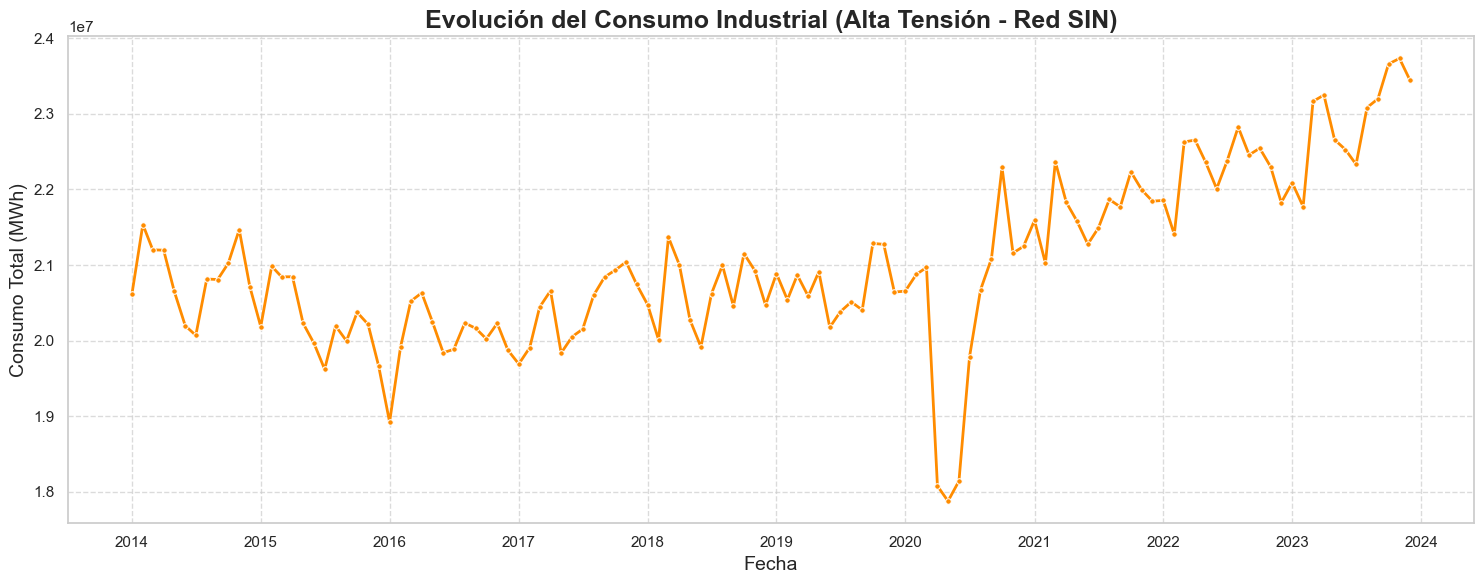

In [56]:
# Convertimos a DataFrame para que Seaborn asigne ejes automáticamente
consumo_nacional = df_dc.groupby(df_dc.index)['Consumo'].sum().reset_index()

plt.figure(figsize=(15, 6))

sns.lineplot(data=consumo_nacional, x='Data', y='Consumo', 
             color='darkorange', linewidth=2, marker='o', markersize=4)


plt.title('Evolución del Consumo Industrial (Alta Tensión - Red SIN)', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Consumo Total (MWh)', fontsize=14) # Agregué una unidad sugerida

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

### Análisis del gráfico.
Se observa que el consumo en Brasil ha seguido una tendencia alcista durante el periodo analizado, lo que refleja un crecimiento constante en la demanda del país. Sin embargo, el momento más impactante ocurre en 2020, donde se ve una caída brusca y profunda causada por el freno de la pandemia. Luego de ese golpe, el país no solo se recuperó rápido, sino que para 2023 alcanzó niveles récord en el consumo. Además, los constantes 'sube y baja' que se repiten cada año nos muestran cómo el clima (como el calor del verano) marca el ritmo del consumo. A este patrón se lo conoce como comportamiento estacional.

### Análisis Temporal y Regional Detallado

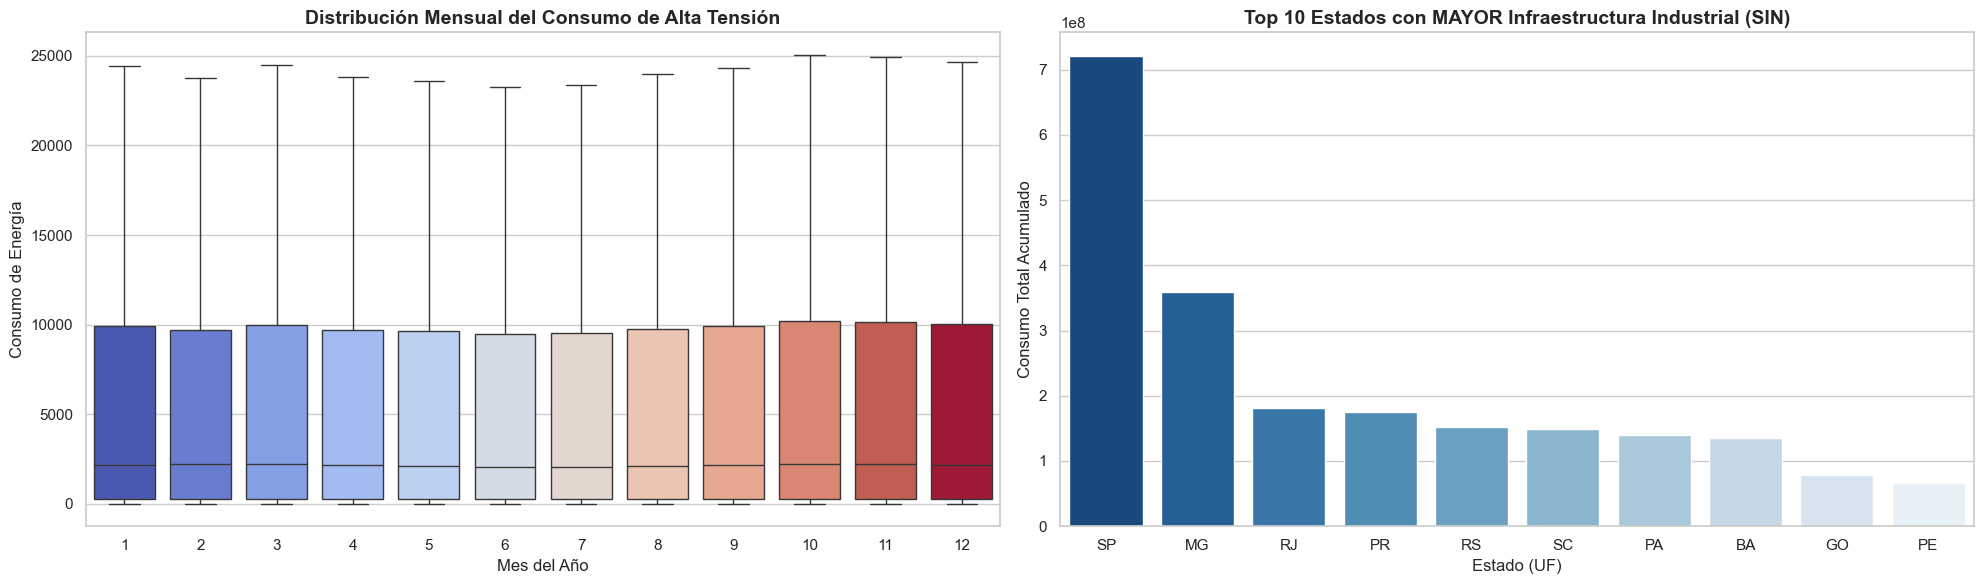

In [ ]:
# --- Estacionalidad y Definición de Infraestructura ---

# 1. Extraer el Mes para agrupar por estacionalidad
df_dc['Mes'] = df_dc.index.month

# Configuramos una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# --- GRÁFICO 1: Estacionalidad Mensual (Buscando el Valle) ---
sns.boxplot(data=df_dc, x='Mes', y='Consumo', ax=axes[0], palette='coolwarm', hue='Mes', legend=False, showfliers=False)
axes[0].set_title('Distribución Mensual del Consumo de Alta Tensión', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mes del Año', fontsize=12)
axes[0].set_ylabel('Consumo de Energía', fontsize=12)

# --- GRÁFICO 2: Definiendo a los "Gigantes" (Top 10 MAYOR Demanda) ---
# Sumamos el consumo para ver quiénes tienen redes de Alta Tensión reales
consumo_por_estado = df_dc.groupby('UF')['Consumo'].sum().sort_values(ascending=False)
estados_alta_infraestructura = consumo_por_estado.head(10)

sns.barplot(x=estados_alta_infraestructura.index, y=estados_alta_infraestructura.values, ax=axes[1], palette='Blues_r', hue=estados_alta_infraestructura.index, legend=False)
axes[1].set_title('Top 10 Estados con MAYOR Infraestructura Industrial (SIN)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Estado (UF)', fontsize=12)
axes[1].set_ylabel('Consumo Total Acumulado', fontsize=12)

plt.tight_layout()
plt.show()

### Definiendo los Parámetros Óptimos
De las visualizaciones anteriores extraemos nuestras dos reglas de negocio finales:
1. **La Ventana (Cuándo):** El mes de **Julio** (pleno invierno) presenta la mediana de consumo más estable y baja, alejándonos de los picos de verano provocados por la refrigeración a nivel nacional.
2. **Los Titanes (Dónde):** Descartamos el 70% del país y nos quedamos solo con los estados que demuestran tener una infraestructura de Alta Tensión masiva (encabezados por SP, MG, RJ, PR y RS).

A continuación, cruzaremos ambas variables para encontrar al ganador definitivo.

Evaluando a la Élite Industrial: ['SP', 'MG', 'RJ', 'PR', 'RS']


C:\Users\nicof\AppData\Local\Temp\ipykernel_22132\4130464482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=consumo_julio_gigantes.index, y=consumo_julio_gigantes.values, palette='magma')


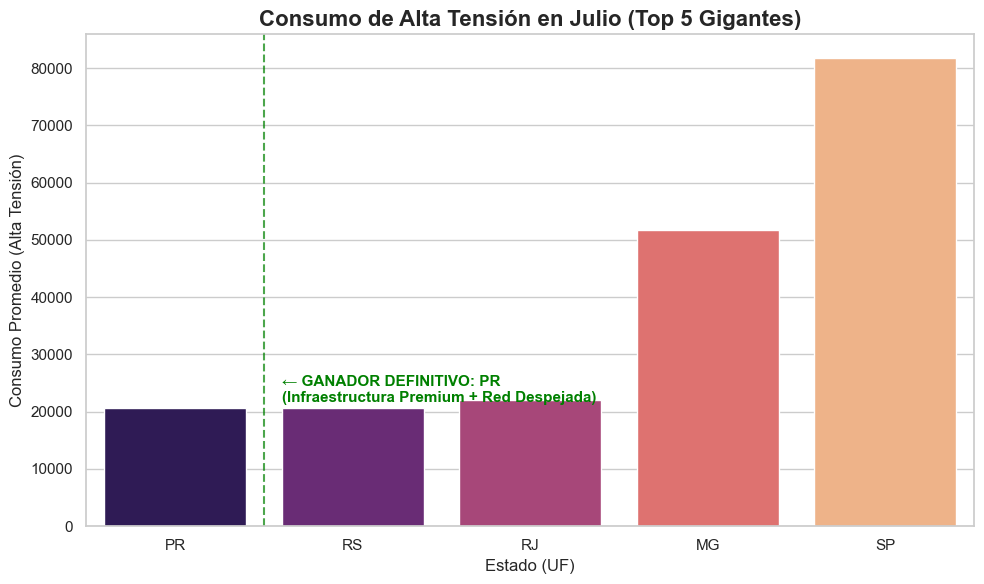

In [40]:
# LA DECISIÓN FINAL (Cruce de Variables) ---

# 1. Seleccionamos el Top 5 de la "Élite" industrial (Para asegurar subestaciones de grado empresarial)
# Usamos el cálculo de la celda anterior
top_5_gigantes = estados_alta_infraestructura.head(5).index.tolist()
print(f"Evaluando a la Élite Industrial: {top_5_gigantes}")

# 2. Filtramos el dataset: SOLO los gigantes Y SOLO en nuestra ventana óptima (Julio)
df_final = df_dc[(df_dc['UF'].isin(top_5_gigantes)) & (df_dc['Mes'] == 7)]

# 3. Calculamos quién tiene el menor consumo promedio en Julio (Buscando "holgura" en la red)
consumo_julio_gigantes = df_final.groupby('UF')['Consumo'].mean().sort_values()

# 4. VISUALIZACIÓN DEL GANADOR
plt.figure(figsize=(10, 6))

sns.barplot(x=consumo_julio_gigantes.index, y=consumo_julio_gigantes.values, palette='magma')

plt.title('Consumo de Alta Tensión en Julio (Top 5 Gigantes)', fontsize=16, fontweight='bold')
plt.xlabel('Estado (UF)', fontsize=12)
plt.ylabel('Consumo Promedio (Alta Tensión)', fontsize=12)

# Resaltar al ganador (El primero de la izquierda, el de menor estrés en la red)
ganador = consumo_julio_gigantes.index[0]
plt.axvline(x=0.5, color='green', linestyle='--', alpha=0.7)
plt.text(0.6, consumo_julio_gigantes.values[0] * 1.05, 
         f'← GANADOR DEFINITIVO: {ganador}\n(Infraestructura Premium + Red Despejada)', 
         color='green', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### Redifinición de Estrategia

### Conclusión Estratégica: Paraná (PR) como Ubicación Óptima

Al aplicar lógica de negocio estricta, descartamos el ruido del consumo residencial y las redes aisladas (contaminantes y riesgosas) para enfocarnos exclusivamente en la **Alta Tensión** del Sistema Interligado Nacional (SIN). Esto reveló a la verdadera "Élite Industrial" de Brasil.

Cruzando esta infraestructura robusta con nuestra ventana climática más estable, el estado de **Paraná durante el mes de Julio** se corona como el ganador definitivo. Esta elección garantiza:

1. **Infraestructura Premium:** Conectividad de Alta Tensión en el núcleo económico.
2. **Cumplimiento ESG:** Red 100% limpia y estable, mitigando apagones.
3. **Eficiencia Operativa:** El "valle" invernal de Julio reduce costos de refrigeración y evita el colapso de la red durante picos de actividad.